# Premières étapes
## Import des packages

In [1]:
# Basique et utilitaire :
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from IPython.display import display, HTML

# Statistiques et prétraitement :
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from category_encoders.target_encoder import TargetEncoder

# Modèles et évaluation :
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Hyperparamétrage 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# Interprétabilité :
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from alibi.explainers import ALE, plot_ale
import lime
from lime import lime_tabular
import shap

c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import des données

In [2]:
df = pd.read_csv('data/raw/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Vérification des doublons
print(df.duplicated().sum())

# Infos sur les données
df.info()

0
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity

Pas de doublons.
6607 observations, 18 variables explicatives pour 1 variable cible : Exam_Score.
Les types des variables semblent bien correspondre aux données.
On constate la présence de valeurs manquantes dans Teacher_Quality, Parental_Education_Level, et Distance_From_Home.

## Train test split
### Séparation

In [4]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vérification de l'équilibre de la variable cible après le split

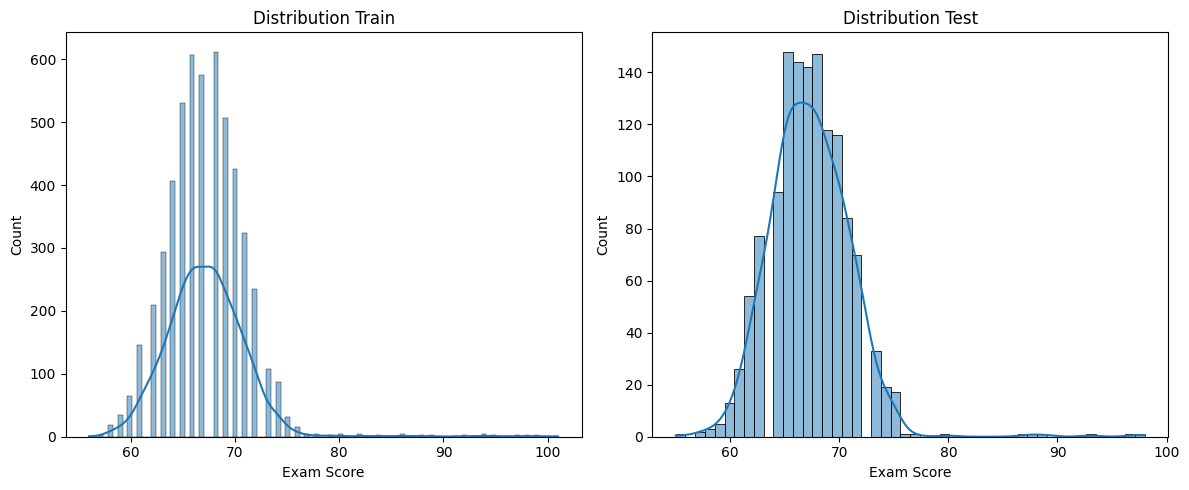

In [5]:
# Vérification sur variables numériques
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Train
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Distribution Train")
axes[0].set_xlabel("Exam Score")

# Test
sns.histplot(y_test, kde=True, ax=axes[1])
axes[1].set_title("Distribution Test")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

La distribution de la variable cible semble bien équilibrée entre le jeu train et le jeu test. Le jeu test est ainsi une bonne représentation du jeu train pour la régression.

### Création d'un df train, test et concatené 
Cela servira à faciliter l'exploration et le nettoyage des données.

In [6]:
# Copie des datasets
df_train = X_train.copy()
df_test = X_test.copy()

# Ajout de la target 
df_train["Exam_Score"] = y_train
df_test["Exam_Score"] = y_test

# Ajout de la source
df_train["__source__"] = "train"
df_test["__source__"] = "test"

# Fusion
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Vérification
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# Exploration et nettoyage des données
## Etapes pré exploration
### Création de listes de variables en fonction du type

In [7]:
# Colonnes quantitatives (numériques)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Colonnes qualitatives catégorielles (texte)
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

### Création d'une palette de couleurs

In [8]:
palette = sns.color_palette("pastel", 10)

## Analyse descriptives univariée
### Variables numériques
Les données contiennent 7 variables quantitatives, dont 1 variable cible, Exam_Score.
#### Statistiques descriptives

In [9]:
df.describe() 

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Les moyennes sont proches des médianes, ce qui indique des distributions plutôt normales. Nous allons vérifier ça à l'aide de visualisation.

#### Visualisation de la distribution

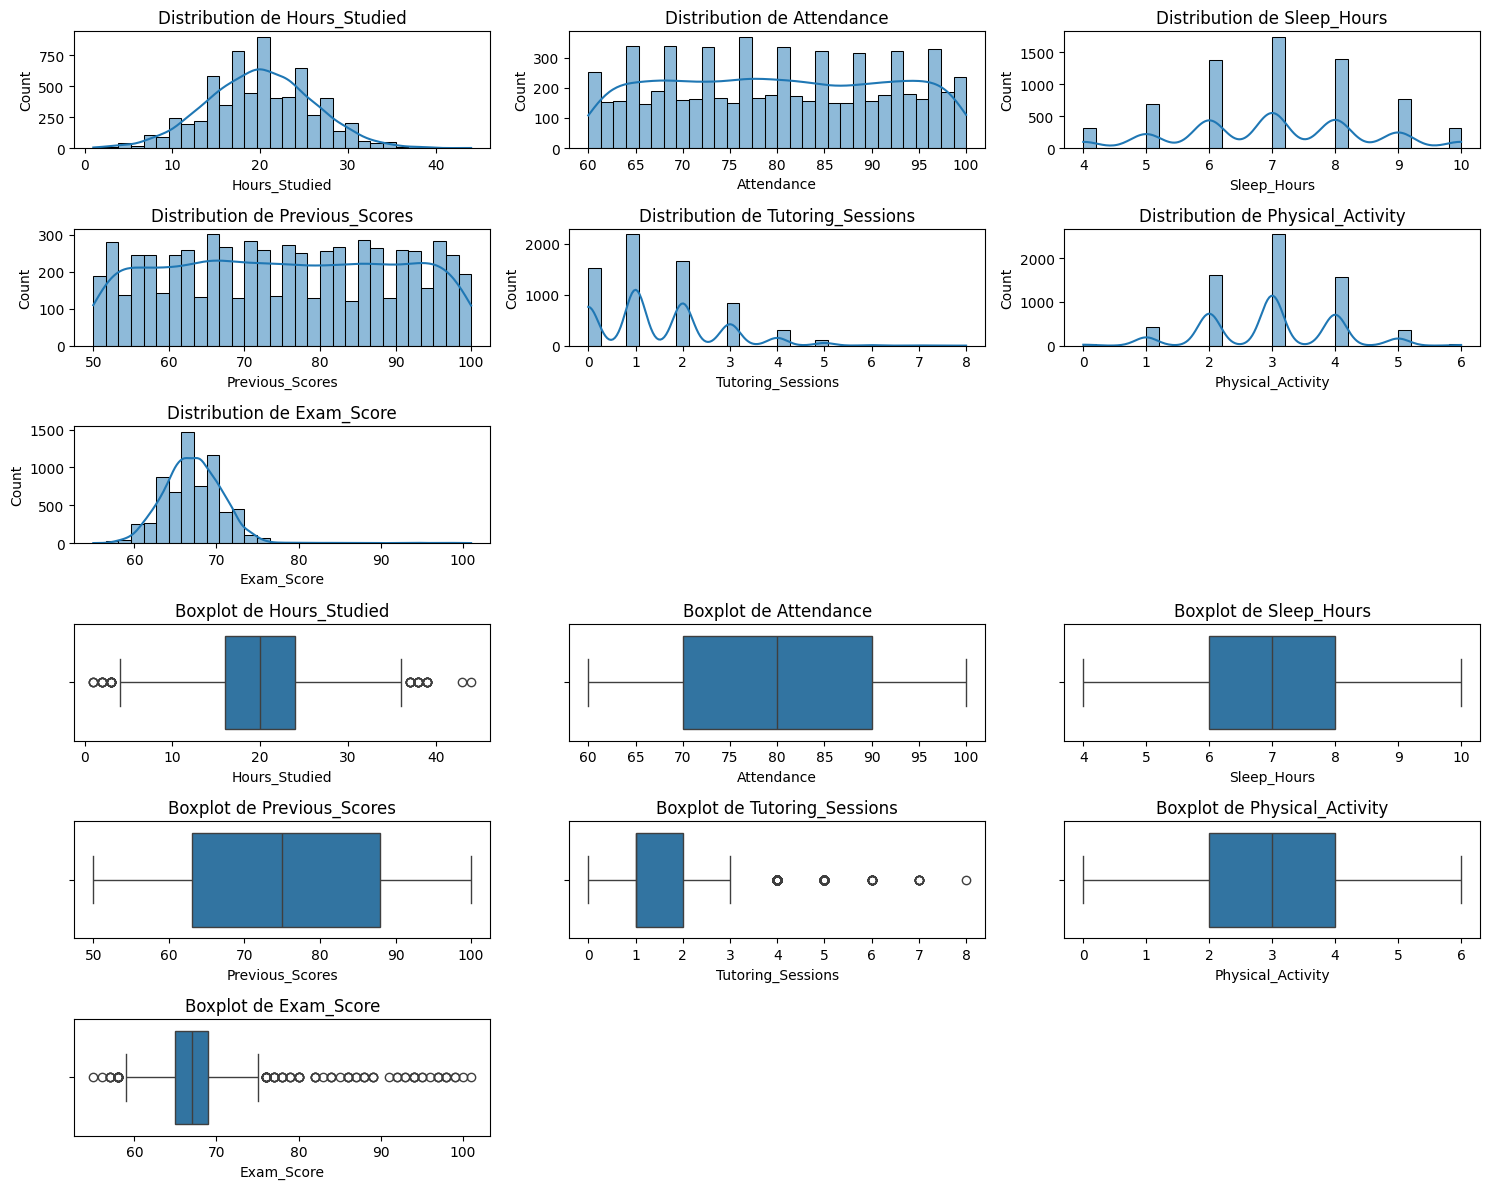

In [10]:
# Histogrammes et Boxplots 

num_cols = df.select_dtypes(include=[np.number]).columns
n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

# Masque les axes vides
for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions des variables quantitatives semblent suivre la Loi Normale, à l'exception de *Attendance*, *Previous_Score* et *Tutoring_Sessions*.
On observe la présence de potentielles valeurs extrêmes dans *Hours_Studied*, *Tutoring_Sessions* et *Exam_Score*.

#### Traitement des valeurs extrêmes
Nous ne traiterons pas les valeurs extrêmes de la variable à prédire *Exam_Score*, afin de ne pas modifier sa distribution.

In [11]:
# Variable cible
target_col = "Exam_Score"

# Colonnes numériques sans la target
num_cols_no_targ = df_train.select_dtypes(include=["int64", "float64"]).columns
num_cols_no_targ = [col for col in num_cols_no_targ if col != target_col]
quantiles = {}

# Calcul uniquement sur les variables numériques
for col in num_cols_no_targ:
    low = df_train[col].quantile(0.01)
    high = df_train[col].quantile(0.99)
    quantiles[col] = (low, high)
    n_changed = ((df_train[col] < quantiles[col][0]) | 
                 (df_train[col] > quantiles[col][1])).sum()
    
    print(f"{col}: {n_changed} valeurs modifiées")

def apply_winsorization(df, quantiles):
    df = df.copy()
    for col, (low, high) in quantiles.items():
        df[col] = df[col].clip(low, high)
    return df

# Application de la winsorization sur les jeux d'entraînement et de test
df_train_no_out = apply_winsorization(df_train, quantiles)
df_test_no_out = apply_winsorization(df_test, quantiles)

# Reconstruction du df complet après nettoyage des valeurs extrêmes
df_no_out = pd.concat([df_train_no_out, df_test_no_out], axis=0, ignore_index=True)

Hours_Studied: 87 valeurs modifiées
Attendance: 0 valeurs modifiées
Sleep_Hours: 0 valeurs modifiées
Previous_Scores: 52 valeurs modifiées
Tutoring_Sessions: 24 valeurs modifiées
Physical_Activity: 59 valeurs modifiées


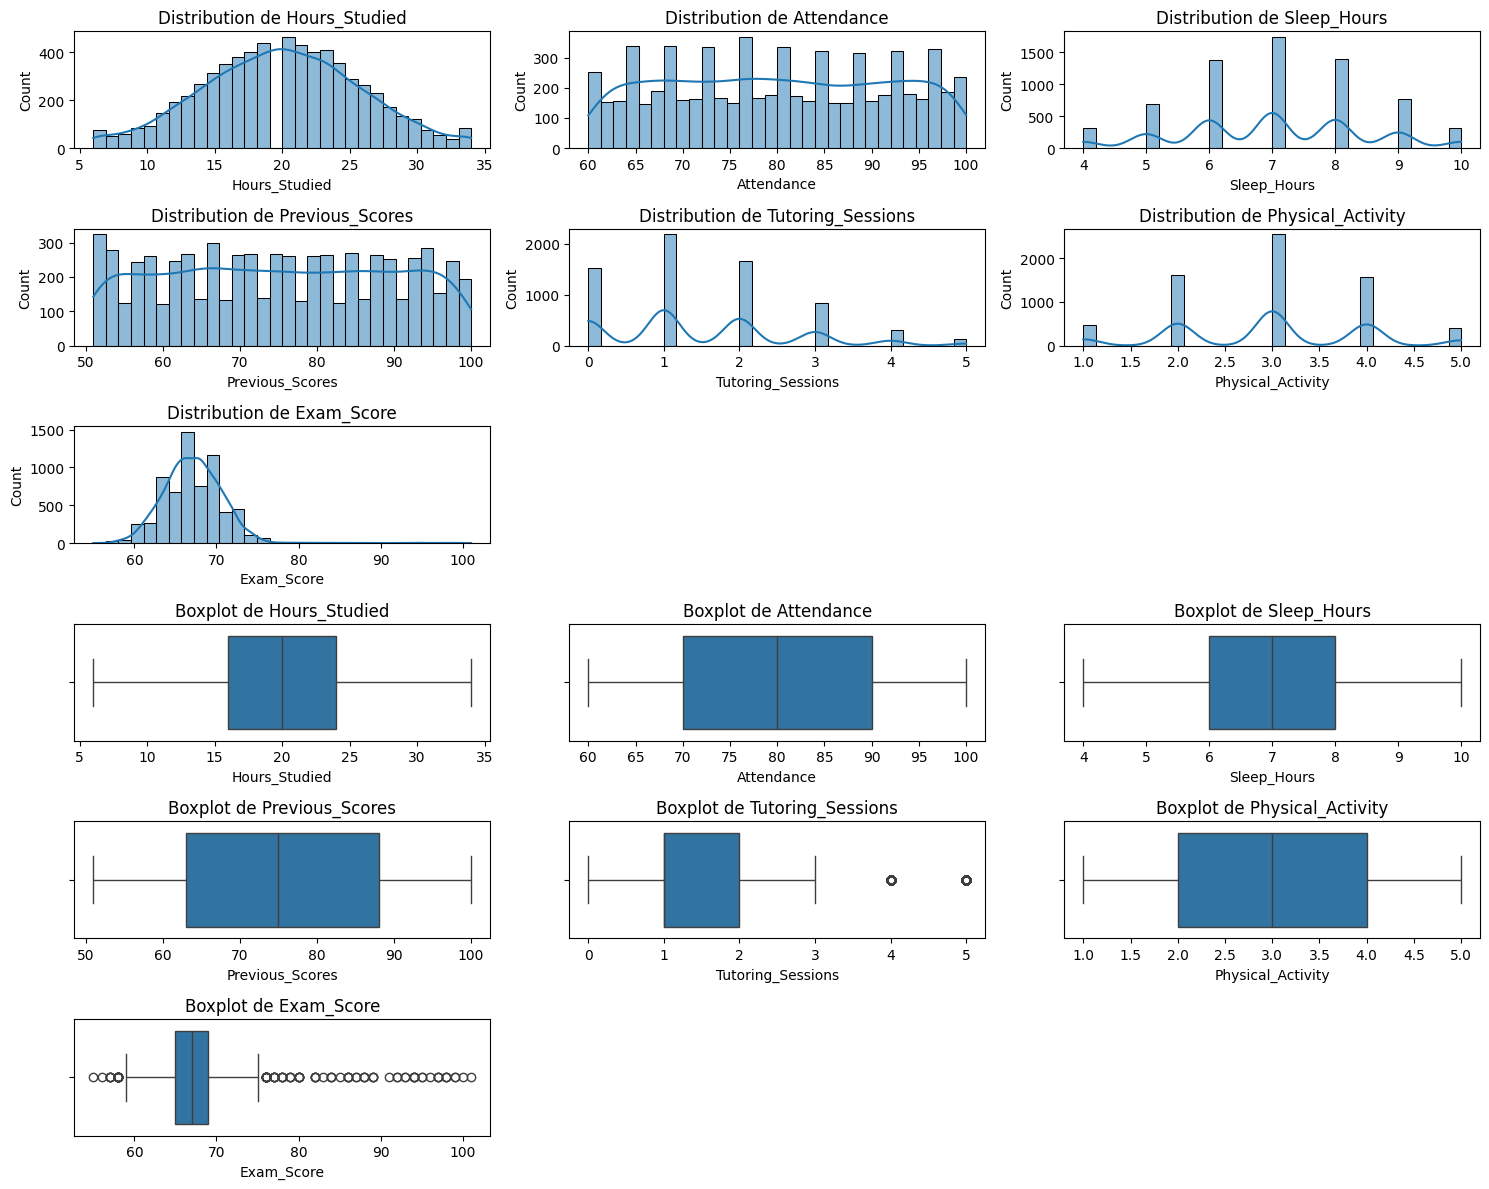

In [12]:
# Distributions après traitements des outliers - Histogrammes et Boxplots

n_vars = len(num_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(
    2 * n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, col in enumerate(num_cols):
    # Indices de ligne / colonne
    row = i // n_cols
    col_idx = i % n_cols

    # Histogramme
    ax_hist = axes[row, col_idx]
    sns.histplot(df_no_out[col], bins=30, kde=True, ax=ax_hist)
    ax_hist.set_title(f"Distribution de {col}")

    # Boxplot
    ax_box = axes[row + n_rows, col_idx]
    sns.boxplot(x=df_no_out[col], ax=ax_box)
    ax_box.set_title(f"Boxplot de {col}")

for j in range(n_vars, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes[r, c].axis("off")
    axes[r + n_rows, c].axis("off")

plt.tight_layout()
plt.show()

Les distributions semblent davantage suivre la Loi Normale et la majorité des potentielles valeurs atypiques ont disparu, sauf pour *Tutoring_Sessions* pour laquelle nous constatons qu'il y a toujours quelques valeurs s'écartant de la médiane.

### Variables catégorielles
#### Observation des distributions

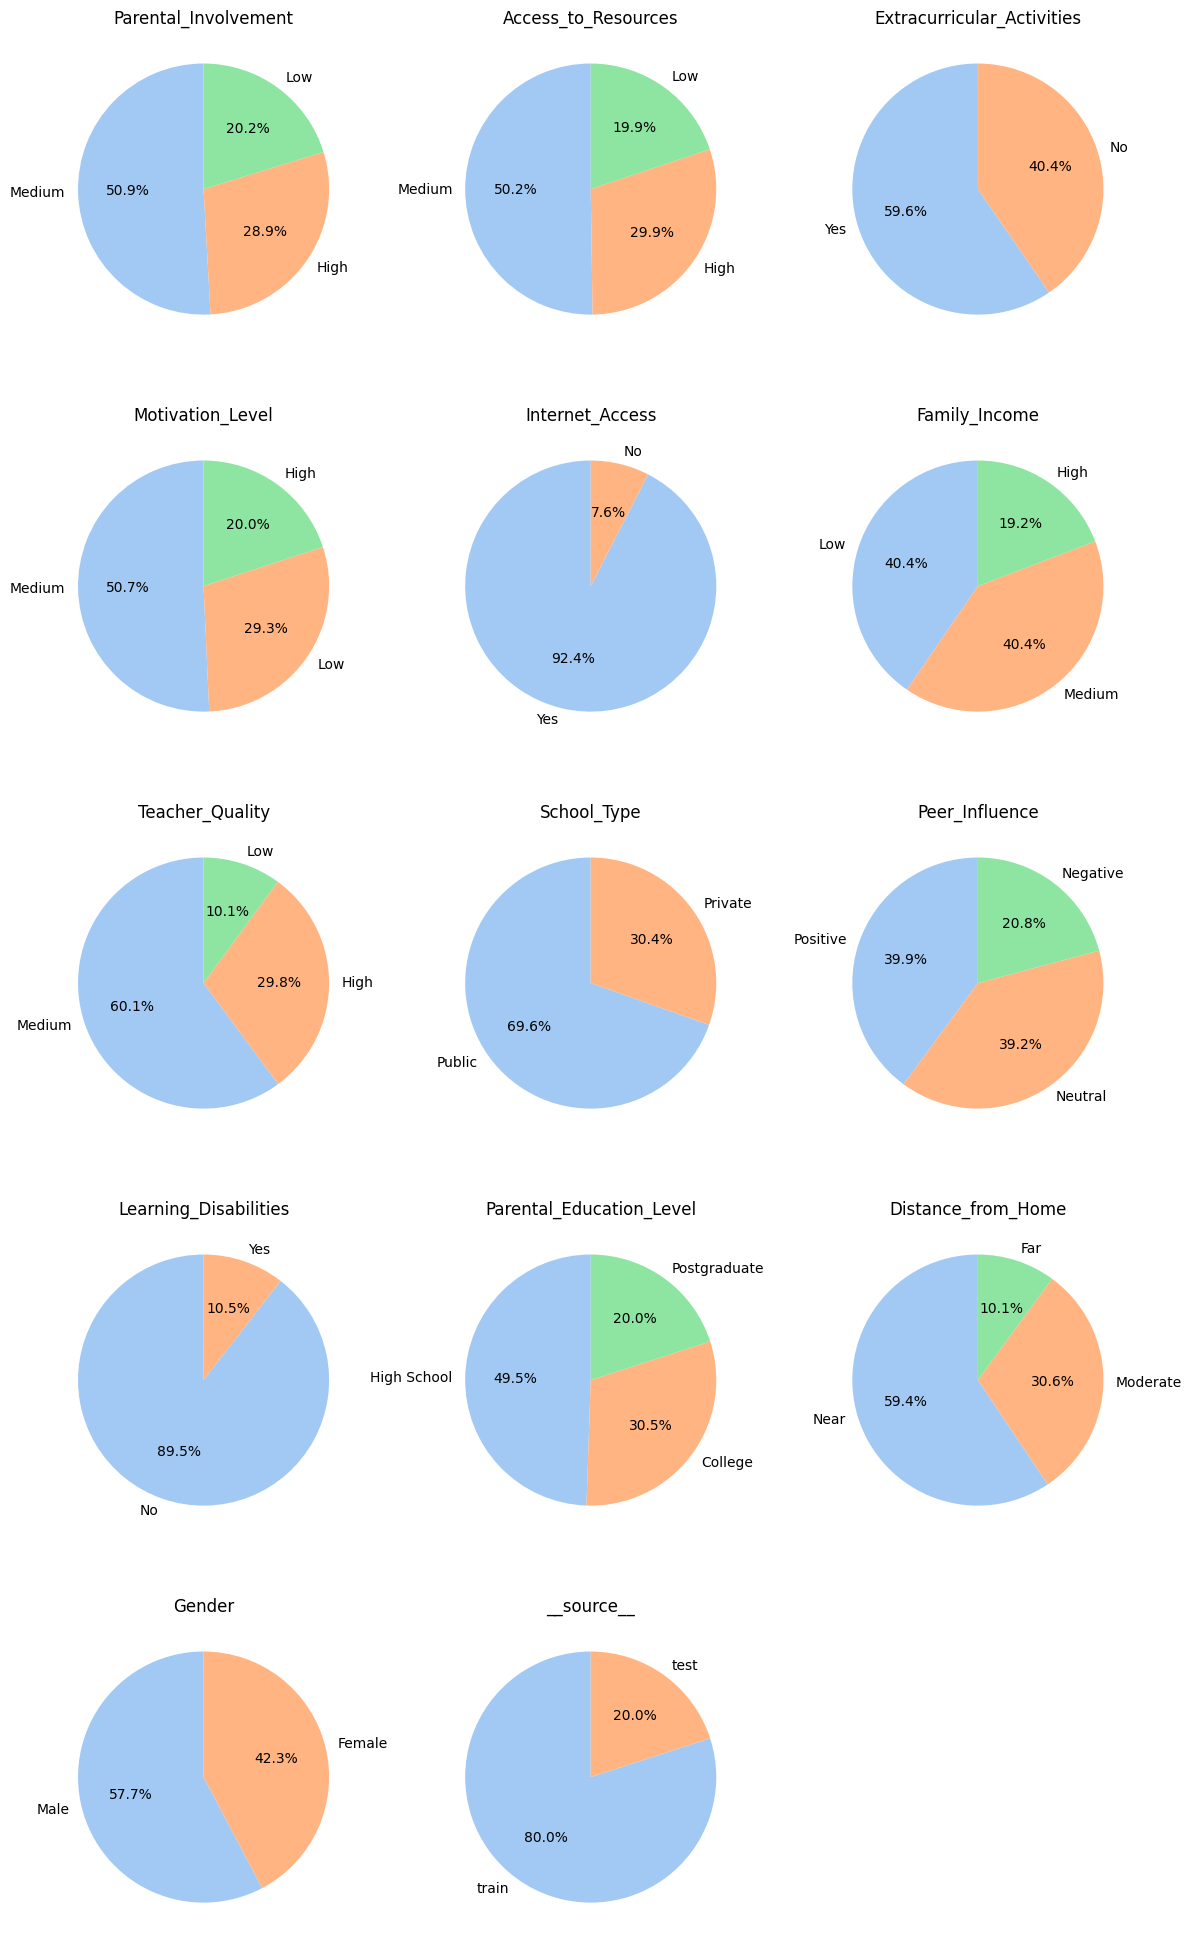

In [13]:
# Pie Chart pour variables catégorielles
def plot_pie(data, columns):

    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        counts = data[col].value_counts()

        axes[i].pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=palette
        )

        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Affichage 
plot_pie(df_no_out, cat_cols)

Les variables catégorielles ne montrent ici pas la présence de modalités avec un très faible pourcentage de valeurs. Il n'est alors pas nécessaire de modifier ces catégories ou d'effectuer un quelconque regroupement.

### Corrélations entre variables explicatives numériques

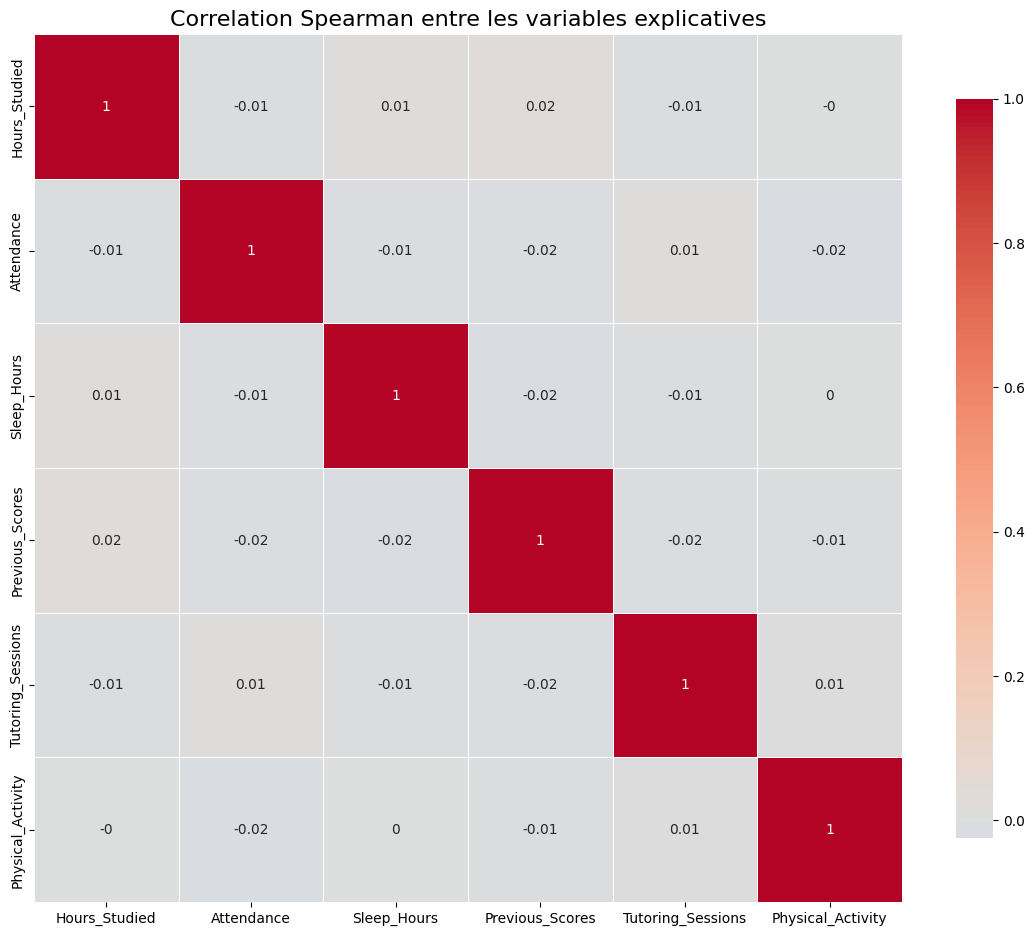

In [ ]:
# Correlation map avec spearman entre les variables explicatives

# Exclusion de la variable cible
x_cols = [c for c in num_cols if c != "Exam_Score"]

# Application de la méthode de corrélation de Spearman
corr = df_no_out[x_cols].corr(method='spearman')

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=corr.round(2), cmap="coolwarm", center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Spearman entre les variables explicatives", fontsize=16)
plt.show()

Le jeu de données étant fictif, nous retrouvons uniquement des corrélations quasiment inexistantes pour les variables de base. Cela ne pose pas de problème pour la réalisation de modèles de regréssions mais cela limite néanmoins le réalisme de ce dataset et donc des résultats que nous obtiendrons.

### Corrélation entre variables qualitatives

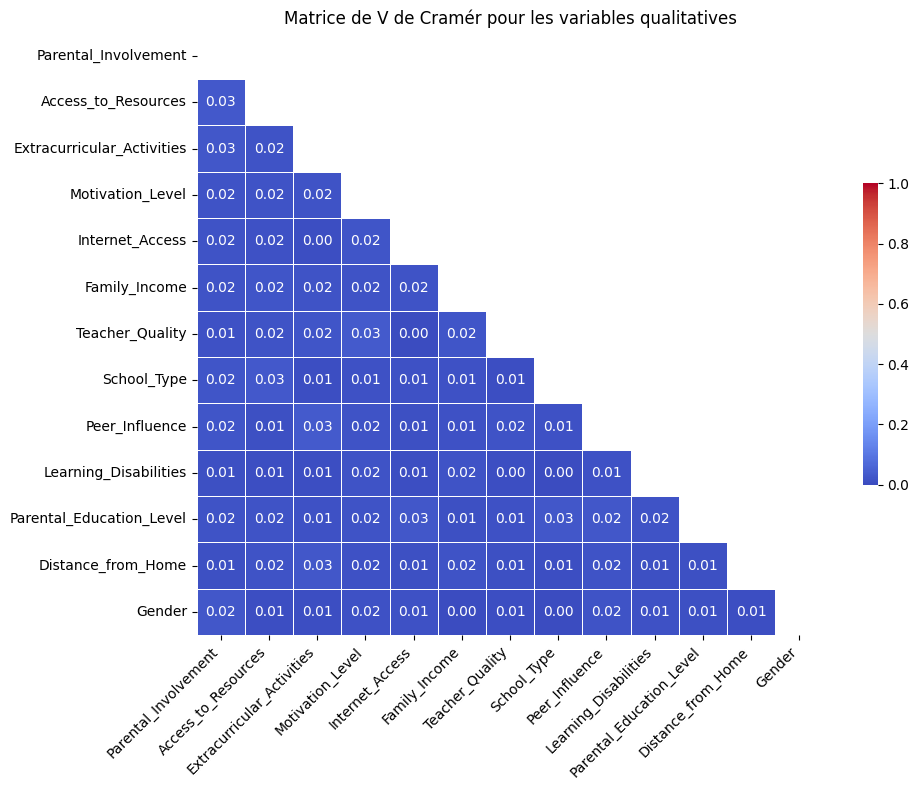

In [15]:
# Matrice de V de Cramer sous forme de heatmap

# Liste des variables catégorielles à analyser, en excluant la source
col_source = "__source__"
cat_cols_no_source = [col for col in df.select_dtypes(include=['str']).columns.tolist() if col != col_source]

# Création de la matrice de V de Cramer
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols_no_source), len(cat_cols_no_source))),
    index=cat_cols_no_source,
    columns=cat_cols_no_source
)

for col1 in cat_cols_no_source:
    for col2 in cat_cols_no_source:
        cramer_matrix.loc[col1, col2] = cramers_v(df_no_out[col1], df_no_out[col2])

## Figure et Heatmap
### Masque pour le triangle supérieur
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))

### Affichage
plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix.astype(float),
    mask=mask,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    center=0.5,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": 0.5},
    annot_kws={"size": 10}
)

plt.title("Matrice de V de Cramér pour les variables qualitatives")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

De la même façon que pour les variables numériques, il n'existe que des corrélations extremement faibles entre les variables qualitatives. 

Dans le cas inverse, nous aurions pu sélectionner les variables à inclure dans notre modèle de telle sorte à ce qu'il n'existe pas de variables fortement corrélées entre elles. Cela pourrait notamment se faire en supprimant une à une les variables les plus corrélées à d'autres, puis en recalculant les corrélations après chaque suppression, jusqu'à ce qu'il n'existe plus de corrélations fortes selon un seuil définit, supérieures à 0,8 par exemple. 

### Analyse des relations entre variables quantitatives et la variables cible

C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1149723631.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1149723631.py:5: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)


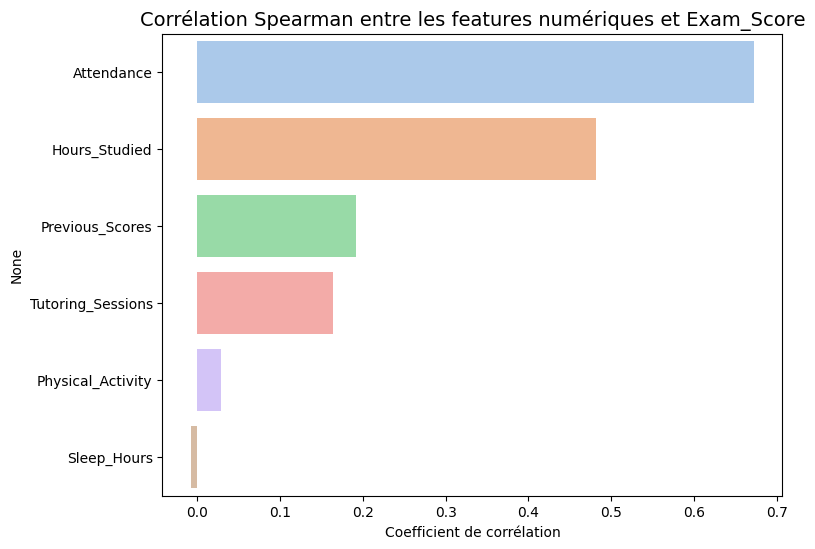

In [16]:
# Corrélation entre les variables explicatives numériques et la variable cible
corr_target = df_no_out[x_cols + ["Exam_Score"]].corr(method="spearman")["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=palette)
plt.title("Corrélation Spearman entre les features numériques et Exam_Score", fontsize=14)
plt.xlabel("Coefficient de corrélation")
plt.show()

*Attendance* et *Hours_Studied* étant fortement corrélés avec la variable cible, cela signifie que dans le dataset, de nombreux élèves ayant une grande assiduité en cours et de nombreuses heures d'études ont obtenu des notes élevées à l'examen final.
Nous pouvons alors supposer que ces variables auront un impact important dans notre modèle.

## Analyse descriptive multivariée
### Analyse des relations entre variables qualitatives et la variable cible

C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1195619092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

<Figure size 1400x3000 with 0 Axes>

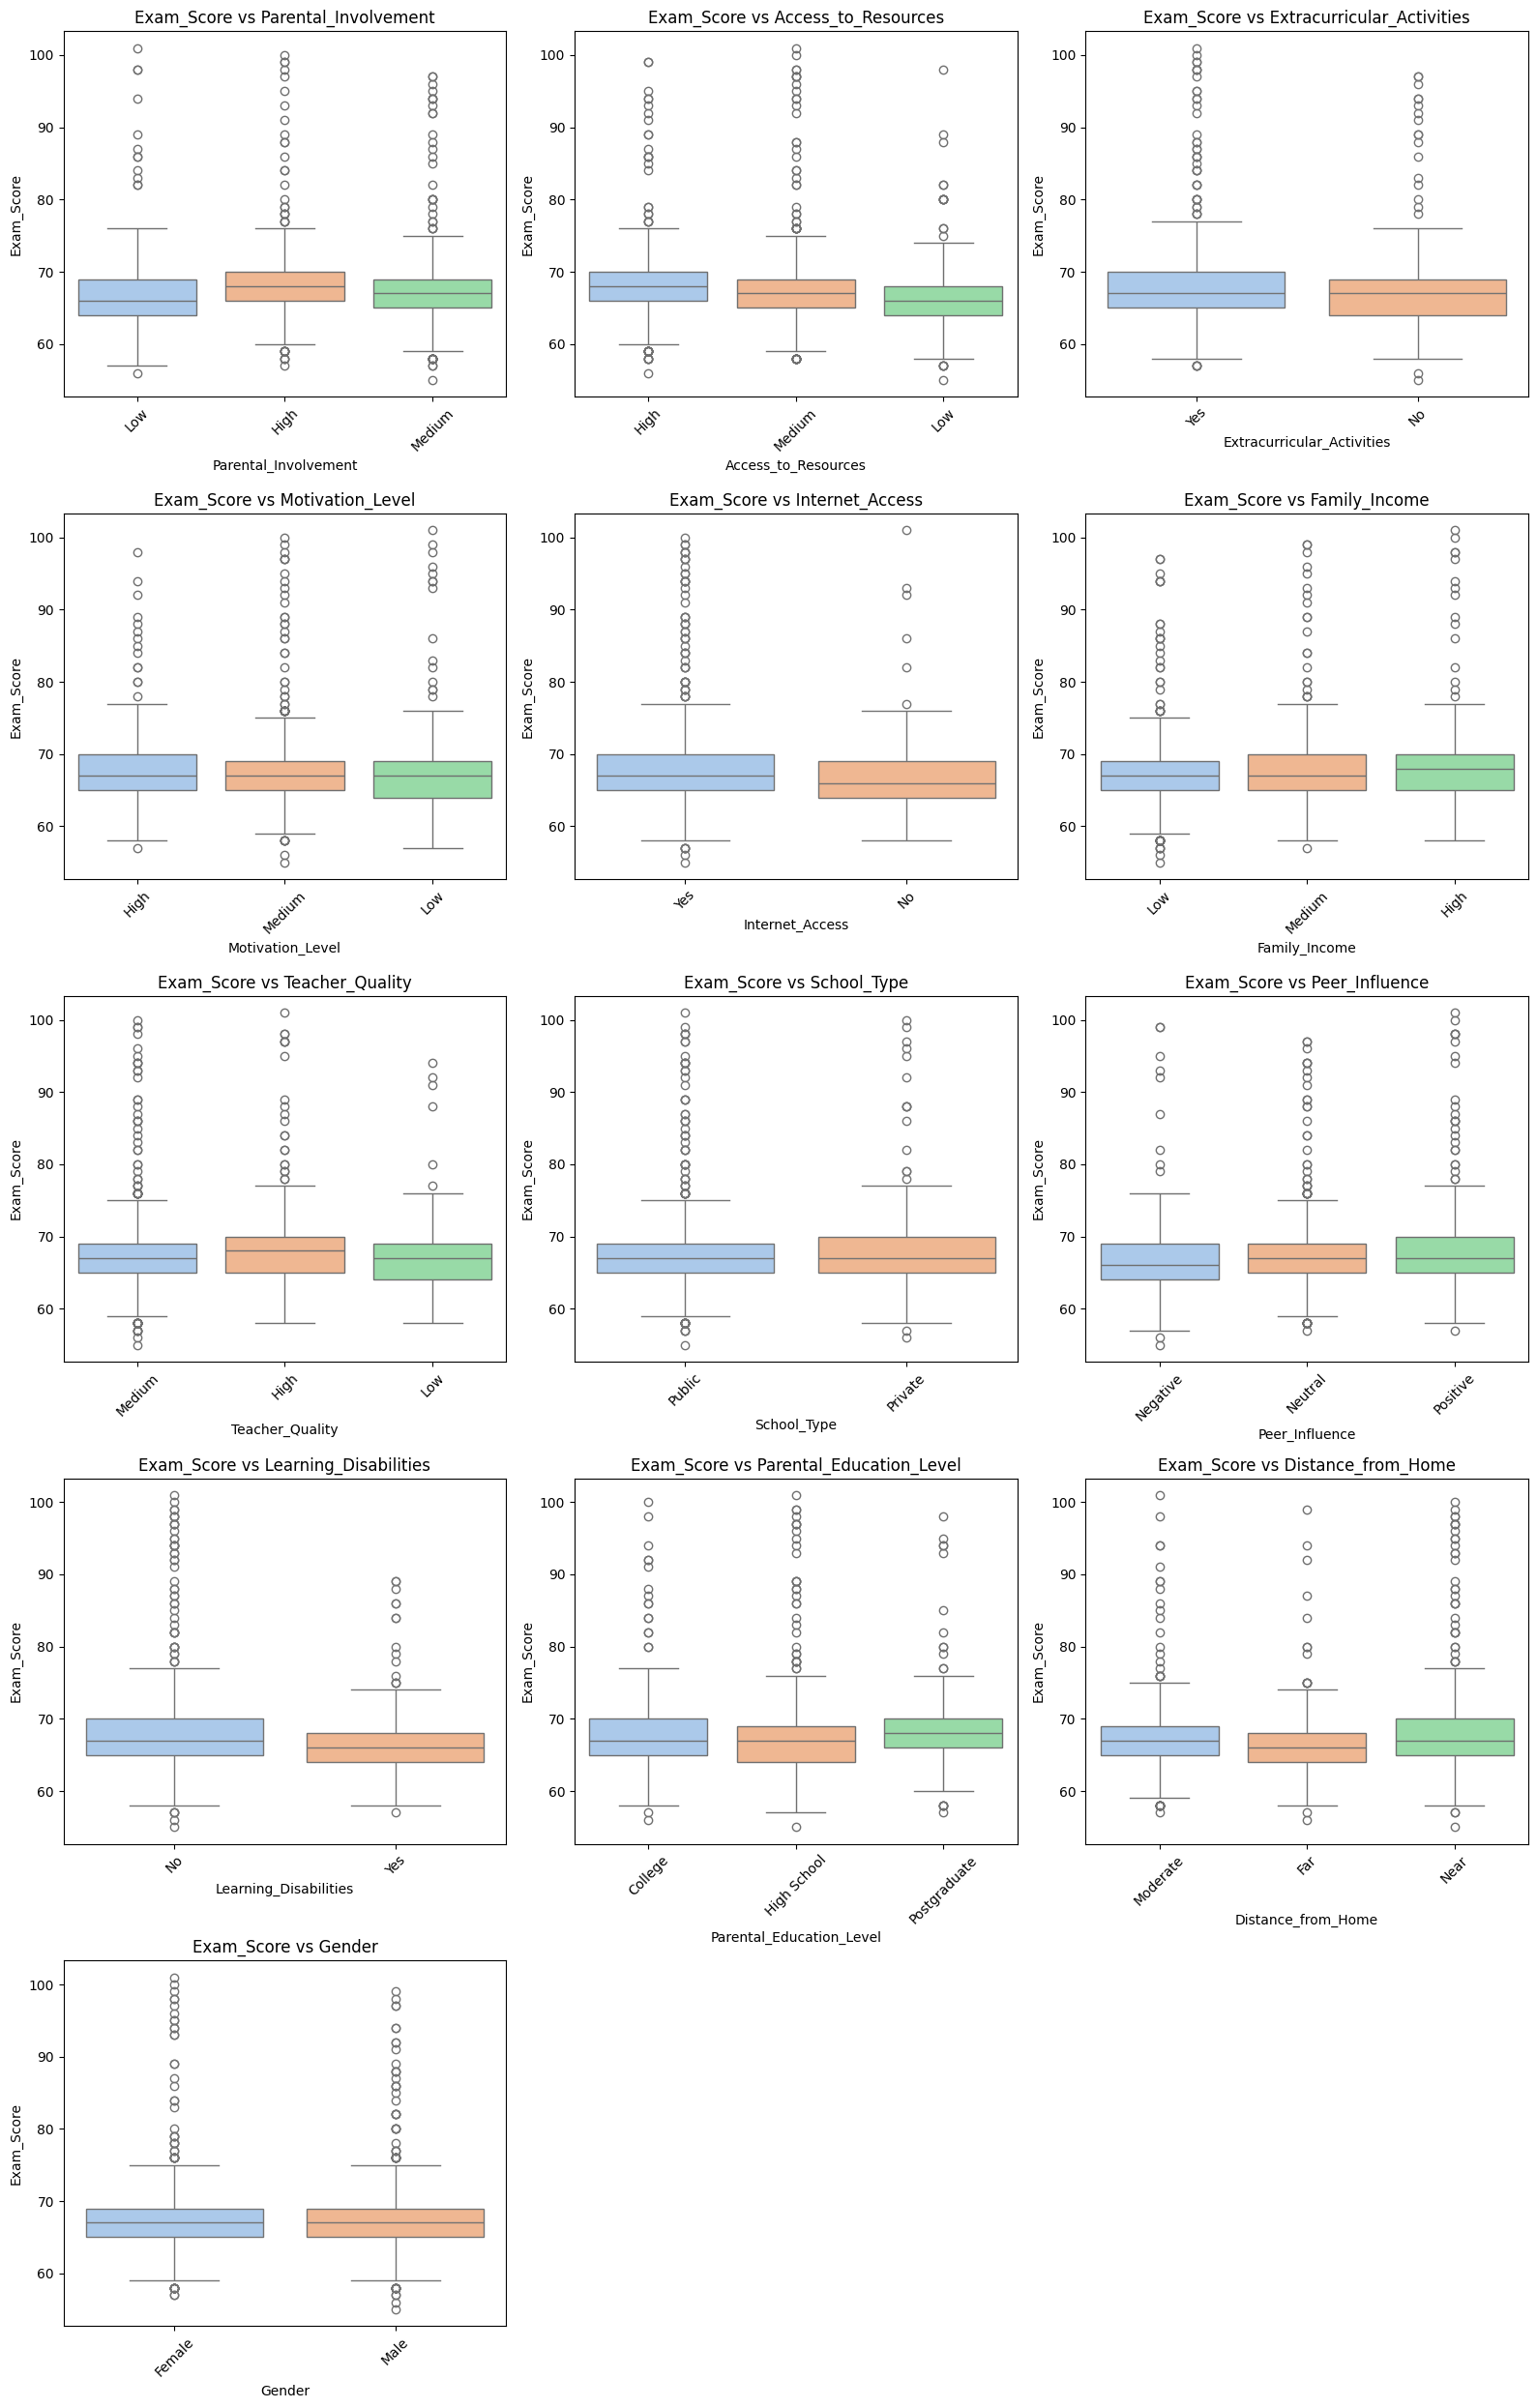

In [17]:
plt.figure(figsize=(14, 30))

# Nombre de variables qualitatives
n_cols = 3
n_rows = (len(cat_cols_no_source) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()

for i, cat in enumerate(cat_cols_no_source):
    sns.boxplot(
        data=df_no_out,
        x=cat,
        y="Exam_Score",
        ax=axes[i],
        palette="pastel"
    )
    axes[i].set_title(f"Exam_Score vs {cat}")
    axes[i].tick_params(axis="x", rotation=45)

# Supprimer les axes vides si le nombre de sous-plots dépasse le nombre de variables
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

En ce qui concerne les variables catégorielles, les associations avec la variable cible sont moins marquées. Cependant, nous pouvons retrouver des variables potentiellement influentes, avec des différences notables, telles que Access_to_Resources, Parental_Involvement, Family_Income ou encore Learning_Disabilities.

# Traitements avant modélisation
## Traitement des valeurs manquantes 
Tout ce qui dépend de statistiques (taux de NA, colonnes à drop, catégories à ajouter) doit être calculé uniquement sur le train, afin d'éviter le data leakage.
Les règles appliquées sur le train seront ensuite appliquées sur le test.

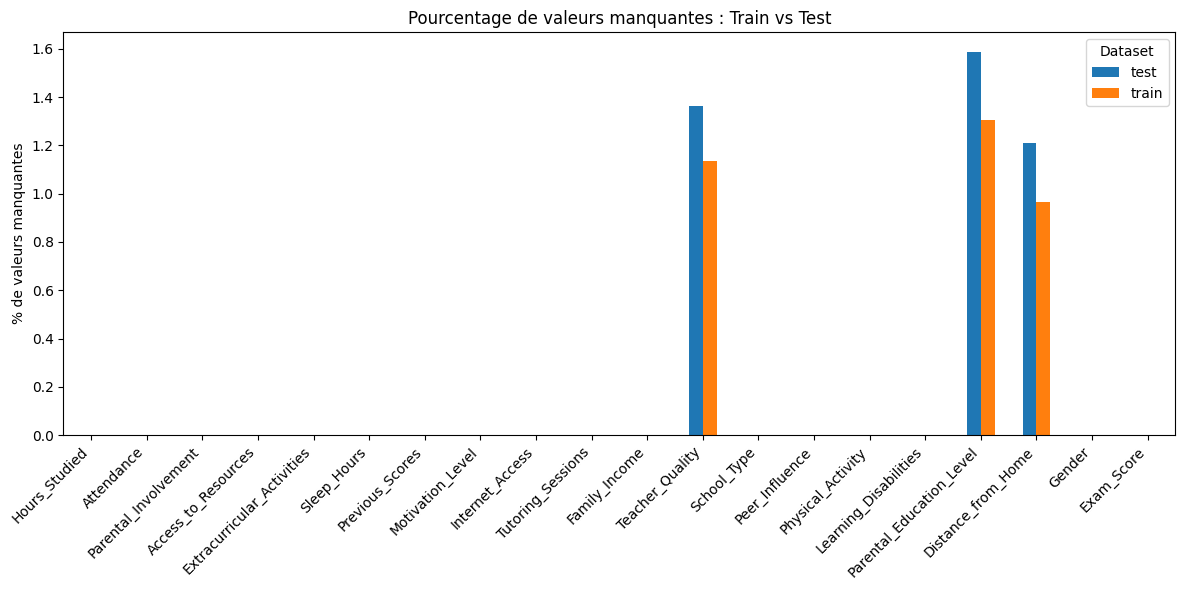

In [ ]:
# Visualisation du pourcentage de valeurs manquantes 
# Calcul du % de valeurs manquantes par colonne et par source
missing_pct = (
    df_no_out.groupby("__source__")
      .apply(lambda x: x.isna().mean() * 100)
      .T  # transpose pour avoir les variables en index
)

# Figure
missing_pct.plot(kind="bar", figsize=(12,6))

plt.title("Pourcentage de valeurs manquantes : Train vs Test")
plt.ylabel("% de valeurs manquantes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

Le pourcentage de valeurs manquantes par variable étant très faibles pour chacune des colonnes concernées, nous pouvons remplacer ces valeurs.
Etant donné que l'analyse descriptive n'a pas permis d'étblir des corrélations importantes entre les différentes variables, et les variables concernées étant de nature catégorielle, nous pouvons remplacer ces valeurs par la modalité la plus fréquente pour chacune.

In [19]:
# Colonnes avec valeurs manquantes
missing_cols = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

# Initialisation de l'imputation avec la modalité la plus fréquente
cat_imputer = SimpleImputer(strategy="most_frequent")

# FIT uniquement sur le train
cat_imputer.fit(df_train_no_out[missing_cols])

# TRANSFORM sur train et test
df_train_no_na = df_train_no_out.copy()
df_test_no_na = df_test_no_out.copy()
df_train_no_na[missing_cols] = cat_imputer.transform(df_train_no_out[missing_cols])
df_test_no_na[missing_cols] = cat_imputer.transform(df_test_no_out[missing_cols])

# Reconstruction du df complet après nettoyage des valeurs manquantes
df_no_na = pd.concat([df_train_no_na, df_test_no_na], axis=0, ignore_index=True)

# Vérification des valeurs manquantes après imputation
print(df_no_na.isna().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
__source__                    0
dtype: int64


# Feature Engineering
## Création de variables
Afin d'améliorer l'éfficacité de notre modèle, nous pouvons essayer d'ajouter une nouvelle variable, crée à partir de nos variables actuelles.
Cette variable représentera l'effet du contexte parentale

In [20]:
# Contexte parentale
df_fe = df_no_na.copy()
df_fe["Parent_Context"] = (
    df_fe["Parental_Education_Level"].astype(str) + "_" +
    df_fe["Family_Income"].astype(str)
)

# Vérification
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6607 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

Ces ajouts ne sont pas fait à partir des statistiques globales, et peuvent donc être fait directement sur le df complet.
Nous devons néanmoins re découper le df en train et test à partir de la colonne source, afin d'appliquer ces modifications sur les df train et test.

In [21]:
# Split train/test depuis le df complet 
df_train_fe = df_fe[df_fe["__source__"] == "train"].copy()
df_test_fe = df_fe[df_fe["__source__"] == "test"].copy()

# Vérification 
print(df_fe.info())
print(df_train_fe.info())
print(df_test_fe.info())

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6607 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

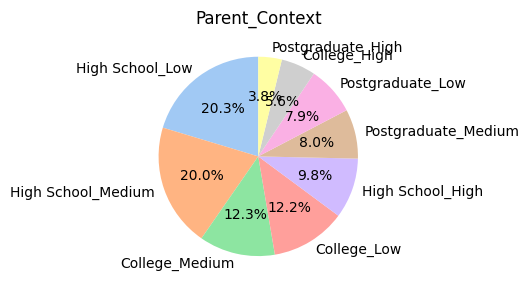

In [22]:
# Distribution de la nouvelle feature
plot_pie(df_fe, ["Parent_Context"])

Puis, *Parent_Context* contient 2 modalités avec peu d'observations (<6%). Afin d'améliorer la pertinence de la variable pour notre modèle, nous pouvons regrouper ces 2 catégories en une seule catégorie "Autres".

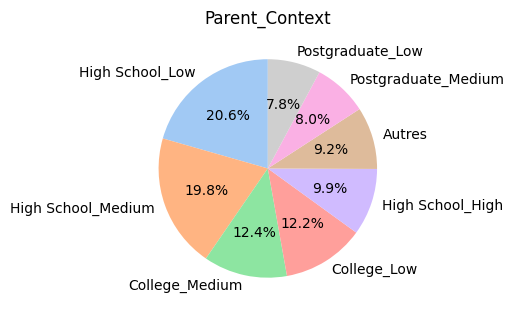

In [ ]:
### Regroupement catégories Parent_Context

# Colonne à traiter
col = "Parent_Context"
threshold = 0.06

# Conversion de col en variable catégorielle dans df_train 
df_train_fe[col] = df_train_fe[col].astype("category")

# Calcul des catégories rares (uniquement sur train)
freq = df_train_fe[col].value_counts(normalize=True)
rare_categories = freq[freq < threshold].index

# Ajout de "Autres"
df_train_fe[col] = df_train_fe[col].cat.add_categories("Autres")

# Remplacement des rares
df_train_fe[col] = df_train_fe[col].replace(rare_categories, "Autres")

# Suppression des anciennes catégories rares
df_train_fe[col] = df_train_fe[col].cat.remove_unused_categories()

# Plot après regroupement
plot_pie(df_train_fe, ["Parent_Context"])

In [ ]:
# Application du même traitement sur le test
df_test_fe[col] = df_test_fe[col].astype("category")
df_test_fe[col] = df_test_fe[col].cat.add_categories("Autres")
df_test_fe[col] = df_test_fe[col].replace(rare_categories, "Autres")
df_test_fe[col] = df_test_fe[col].cat.remove_unused_categories()

# Concaténation du df complet après regroupement des catégories rares
df_fe = pd.concat([df_train_fe, df_test_fe], axis=0, ignore_index=True)

# Vérification de la distribution après regroupement
df_fe["Parent_Context"].value_counts(normalize=True)

Parent_Context
High School_Low        0.203421
High School_Medium     0.200091
College_Medium         0.123203
College_Low            0.121840
High School_High       0.097926
Autres                 0.094143
Postgraduate_Medium    0.080218
Postgraduate_Low       0.079158
Name: proportion, dtype: float64

In [25]:
# Reconstruction des X_train et X_test après imputation et transformations
X_train = df_train_fe.drop(columns=["__source__"])
X_test = df_test_fe.drop(columns=["__source__"])

## Encodage des variables catégorielles
L'encodage doit être fait sur train pour éviter le data leakage.
Plusieurs méthodes sont possibles, notamment les suivantes : 
- One-Hot Encoding, pour les variables avec peu de modalités 
- Target Encoding, pour les variables avec beaucoup de modalités 
- Ordinal Encoder, lorsqu'on veut conserver l'odre naturel des catégories
- ...

### Définition des règles
Nous utiliserons ici le One-Hot Encoding pour les variables avec 3 modalités ou moins, et le Target Encoding pour celles avec plus de 3 modalités.

In [26]:
# Variable cible
TARGET = "Exam_Score"

# On remet "Parent_Context" en format str
df_train_fe[col] = df_train_fe[col].astype('str')

# Colonnes catégorielles
cat_cols = [col for col in df_train_fe.select_dtypes(include="object").columns 
            if col not in ["__source__", "Exam_Score"]] 

# Séparation selon le nombre de modalités
cat_ohe = [c for c in cat_cols if df_train_fe[c].nunique() <= 3]
cat_target = [c for c in cat_cols if df_train_fe[c].nunique() > 3]

print("Variables en One-Hot Encoding :", cat_ohe)
print("Variables en Target Encoding :", cat_target)

Variables en One-Hot Encoding : ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Variables en Target Encoding : ['Parent_Context']


C:\Users\isali\AppData\Local\Temp\ipykernel_33488\1755839059.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in df_train_fe.select_dtypes(include="object").columns


### Encodage Train et fit

In [27]:
# One-Hot encoding
ohe = OneHotEncoder(
    sparse_output=False,
    drop=None,
    handle_unknown="ignore"
)

X_ohe = pd.DataFrame(
    ohe.fit_transform(df_train_fe[cat_ohe]),
    columns=ohe.get_feature_names_out(cat_ohe),
    index=df_train_fe.index
)

In [28]:
# Target encoding
te = TargetEncoder(
    cols=cat_target,
    smoothing=10  # régularisation (important pour éviter l'overfitting)
)

X_te = te.fit_transform(
    df_train_fe[cat_target],
    df_train_fe[TARGET]
)

In [29]:
# Variables numériques (hors cible)
num_cols = df_train_fe.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
X_num = df_train_fe[num_cols]

# Dataset final prêt pour la modélisation
X = pd.concat(
    [X_num, X_ohe, X_te],
    axis=1
)
y = df_train_fe[TARGET]

# Vérification
print("Shape X :", X.shape)
print("Shape y :", y.shape)

encoded_train = pd.concat(
    [X, y],
    axis=1
)
print(encoded_train.head())

Shape X : (5285, 41)
Shape y : (5285,)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             27          79            8               63                  2   
1             16          86            7               94                  2   
2             22          87            8               83                  1   
3             18         100           10               86                  1   
4             34          78           10               99                  1   

   Physical_Activity  Parental_Involvement_High  Parental_Involvement_Low  \
0                  5                        0.0                       1.0   
1                  3                        1.0                       0.0   
2                  1                        0.0                       1.0   
3                  3                        1.0                       0.0   
4                  2                        1.0                       0.0   

   Parental

### Encodage Test

In [30]:
# Encodage test (réutilisation de celui du train, pour éviter la fuite d'information)
# Encodage One-Hot pour les variables avec 3 modalités ou moins
X_ohe_test = pd.DataFrame(
    ohe.transform(df_test_fe[cat_ohe]),  # on utilise ohe déjà fit sur le train
    columns=ohe.get_feature_names_out(cat_ohe),
    index=df_test_fe.index
)

# Encodage Target pour les variables avec > 3 modalités
X_te_test = te.transform(df_test_fe[cat_target])  # on utilise te déjà fit sur le train

# Variables numériques
num_cols_test = df_test_fe.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
# On exclut la cible si elle est présente dans le test
num_cols_test = [c for c in num_cols_test if c != TARGET]
X_num_test = df_test_fe[num_cols_test]

# Assemblage du dataset test
X_test = pd.concat([X_num_test, X_ohe_test, X_te_test], axis=1)

# Vérification
print("Shape X_test :", X_test.shape)
print(X_test.head())

y_test = df_test_fe[TARGET]
encoded_test = pd.concat([X_test, y_test], axis=1)

Shape X_test : (1322, 41)
      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
5285             20          71            7               87   
5286             22          71            7               98   
5287             21          91            6               53   
5288             12          91            8               81   
5289             21          63            8               95   

      Tutoring_Sessions  Physical_Activity  Parental_Involvement_High  \
5285                  1                  5                        0.0   
5286                  2                  2                        0.0   
5287                  1                  3                        1.0   
5288                  0                  4                        0.0   
5289                  2                  5                        0.0   

      Parental_Involvement_Low  Parental_Involvement_Medium  \
5285                       0.0                          1.0   
5286              

In [31]:
# Définition de X et y
X_train = encoded_train.drop('Exam_Score', axis=1)
y_train = encoded_train['Exam_Score']
X_test = encoded_test.drop('Exam_Score', axis=1)
y_test = encoded_test['Exam_Score']

# Concaténation des jeux de données train et test
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

# Vérification
print("Shape X train :", X_train.shape)
print("Shape y train :", y_train.shape)
print("Shape X test :", X_test.shape)
print("Shape y test :", y_test.shape)
print("Shape X :", X.shape)

Shape X train : (5285, 41)
Shape y train : (5285,)
Shape X test : (1322, 41)
Shape y test : (1322,)
Shape X : (6607, 41)


## Normalisation des features
Les variables n'ayant pas la même échelle de mesure, il est important de les normaliser afin de rendre les coefficients comparables dans le cadre de certains modèles de Machine Learning.

In [33]:
# Identification des variables numériques et target encodés à scaler
cols_to_scale = [
    "Hours_Studied", "Attendance", "Sleep_Hours", 
    "Previous_Scores", "Tutoring_Sessions", 
    "Physical_Activity", "Parent_Context"
]

scaler = StandardScaler()

# Copies
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Fit sur train uniquement
X_train_sc[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform sur test
X_test_sc[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Vérification de la shape
print(X_train_sc.shape, X_test_sc.shape, y_train.shape, y_test.shape)
print(X_train_sc.head())

(5285, 41) (1322, 41) (5285,) (1322,)
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0       1.193757   -0.075846     0.669094        -0.838937           0.418309   
1      -0.673466    0.531894    -0.016740         1.315578           0.418309   
2       0.345019    0.618714     0.669094         0.551073          -0.407218   
3      -0.333971    1.747376     2.040764         0.759574          -0.407218   
4       2.381990   -0.162667     2.040764         1.663081          -0.407218   

   Physical_Activity  Parental_Involvement_High  Parental_Involvement_Low  \
0           2.016522                        0.0                       1.0   
1           0.029514                        1.0                       0.0   
2          -1.957495                        0.0                       1.0   
3           0.029514                        1.0                       0.0   
4          -0.963990                        1.0                       0.0   

   Parental_

# Modélisation
## Fonction d'évaluation des modèles

In [ ]:
def evaluate_model(model, X_test, y_test):
    # Fonction pour évaluer les modèles de régression

    # Prédiction des valeurs de la variable cible pour les données de test
    y_pred = model.predict(X_test)
    # Retourne le R2
    print(f"Évaluation du modèle : {model.__class__.__name__}")
    r2 = r2_score(y_test, y_pred)
    print(f"R²   : {r2:.4f}")
    # Retourne les métriques MSE et MAE
    print(f"Performance sur le jeu de test :")
    # Calcul du MSE
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE  : {mse:.4f}")
    # Calcul du MAE
    mae = mean_absolute_error(y_test, y_pred)
    print(f"MAE  : {mae:.4f}")
    return None

## Modèles 
Pour chacun des modèles autre que la Régression Linéaire, nous chercherons les meilleurs hyperparamètres, dans un premier temps à l'aide d'un Randomized Search, nous permettant de balayer un large éventail de possibilités, uis avec un Grid Search autour des meilleurs hyperparamètres ressortant.
Cela nous permettra d'optimiser les modèles afin d'obtenir la meilleur performance.

### Régression Linéaire

In [35]:
# Création du modèle
lr = LinearRegression()

# Entrainement
lr.fit(X_train_sc, y_train)

# Prédictions
y_pred = lr.predict(X_test_sc)

# Evaluation
evaluate_model(lr, X_test_sc, y_test)

Évaluation du modèle : LinearRegression
R²   : 0.7682
Performance sur le jeu de test :
MSE  : 3.2762
MAE  : 0.4619


In [36]:
# Coefficients
coef_df = pd.DataFrame({
    "feature": X_train_sc.columns,
    "coefficient": lr.coef_
})

print(coef_df.sort_values(by="coefficient", ascending=False))

                                  feature  coefficient
1                              Attendance     2.292790
0                           Hours_Studied     1.759332
9                Access_to_Resources_High     1.045749
6               Parental_Involvement_High     1.031008
3                         Previous_Scores     0.709115
4                       Tutoring_Sessions     0.625722
14                  Motivation_Level_High     0.533486
22                   Teacher_Quality_High     0.527850
19                     Family_Income_High     0.517824
29                Peer_Influence_Positive     0.514512
18                    Internet_Access_Yes     0.477351
37                Distance_from_Home_Near     0.463891
34  Parental_Education_Level_Postgraduate     0.427835
30               Learning_Disabilities_No     0.427006
13         Extracurricular_Activities_Yes     0.290284
5                       Physical_Activity     0.200671
40                         Parent_Context     0.067017
28        

### Random Forest
#### Random Search

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf_param_dist = {
    "n_estimators": stats.randint(100, 1000),
    "max_depth": stats.randint(3, 30),
    "min_samples_split": stats.randint(2, 20),
    "min_samples_leaf": stats.randint(1, 10),
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=60,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_random.fit(X_train_sc, y_train)

print("Best RF params:", rf_random.best_params_)
# {'max_depth': 21, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 727}

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best RF params: {'max_depth': 21, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 727}


#### Grid Search

In [ ]:
rf = RandomForestRegressor(random_state=42)

# Définition de la grille de recherche des hyperparamètres
rf_param_grid = {
    'n_estimators': [690, 720, 750, 800],
    'max_depth': [15, 20, 21, 25],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [2, 4, 6, 8]
}

# Grid Search avec validation croisée, par rapport au r2
grid_search_rf = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=5, n_jobs=-1, scoring="neg_root_mean_squared_error", 
                              verbose=2)
grid_search_rf.fit(X_train_sc, y_train)
print(grid_search_rf.best_params_)
# {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 800}

Fitting 5 folds for each of 192 candidates, totalling 960 fits
{'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 800}


#### Modèle optimisé

In [37]:
# Création du modèle
rf = RandomForestRegressor(n_estimators=800,
                            max_depth=20,
                            min_samples_split=2,
                            min_samples_leaf=4,
                            random_state=42)

# Entrainement 
rf.fit(X_train_sc, y_train)

# Prédictions des valeurs de la variable cible pour les données de test
y_pred_rf = rf.predict(X_test_sc)

# Evaluation 
evaluate_model(rf, X_test_sc, y_test)

Évaluation du modèle : RandomForestRegressor
R²   : 0.6915
Performance sur le jeu de test :
MSE  : 4.3603
MAE  : 1.0367


### Adaboost
#### Random Search

In [ ]:
ada = AdaBoostRegressor(random_state=42)

ada_param_dist = {
    "n_estimators": stats.randint(50, 500),
    "learning_rate": stats.loguniform(0.01, 1),
    "loss": ["linear", "square", "exponential"]
}

ada_random = RandomizedSearchCV(
    ada,
    param_distributions=ada_param_dist,
    n_iter=60,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

ada_random.fit(X_train_sc, y_train)

print("Best Ada params:", ada_random.best_params_)
# {'learning_rate': np.float64(0.0134003672433548), 'loss': 'exponential', 'n_estimators': 111}

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Ada params: {'learning_rate': np.float64(0.0134003672433548), 'loss': 'exponential', 'n_estimators': 111}


#### Grid Search

In [ ]:
adaboost = AdaBoostRegressor(random_state=42)
adaboost_param_grid = {
    'n_estimators': [100, 125, 150],
    'estimator': [DecisionTreeRegressor(max_depth=d) for d in [3, 4, 5]],
    'loss': ['exponential'],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_search_adaboost = GridSearchCV(estimator=adaboost, param_grid=adaboost_param_grid, cv=5, n_jobs=-1, scoring="neg_root_mean_squared_error", 
                                    verbose=2)
grid_search_adaboost.fit(X_train_sc, y_train)
print(grid_search_adaboost.best_params_)
# {'estimator': DecisionTreeRegressor(max_depth=5), 'learning_rate': 0.01, 'loss': 'exponential', 'n_estimators': 100}

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'estimator': DecisionTreeRegressor(max_depth=5), 'learning_rate': 0.01, 'loss': 'exponential', 'n_estimators': 100}


#### Modèle optimisé

In [38]:
# Création du modèle
adb = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                            n_estimators=100,
                            loss='exponential',
                            learning_rate=0.01,
                            random_state=42)

# Entrainement du modèle
adb.fit(X_train_sc, y_train)

# Prédictions
y_pred_adb = adb.predict(X_test_sc)

# Evaluation du modèle
evaluate_model(adb, X_test_sc, y_test)

Évaluation du modèle : AdaBoostRegressor
R²   : 0.6013
Performance sur le jeu de test :
MSE  : 5.6354
MAE  : 1.4373


### XGBoost
#### Random Search

In [ ]:
xgb = XGBRegressor(random_state=42, verbosity=0)

xgb_param_dist = {
    "n_estimators": stats.randint(100, 1000),
    "max_depth": stats.randint(3, 12),
    "learning_rate": stats.loguniform(0.01, 0.3),
    "subsample": stats.uniform(0.6, 0.4),
    "colsample_bytree": stats.uniform(0.6, 0.4),
    "gamma": stats.uniform(0, 0.5),
    "reg_alpha": stats.loguniform(1e-4, 1),
    "reg_lambda": stats.loguniform(1e-3, 10)
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_dist,
    n_iter=60,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

xgb_random.fit(X_train_sc, y_train)

print("Best XGB params:", xgb_random.best_params_)
# {'colsample_bytree': np.float64(0.9003484271165989), 'gamma': np.float64(0.3772714370423412), 
# 'learning_rate': np.float64(0.014201246261716191), 'max_depth': 3, 'n_estimators': 980, 
# 'reg_alpha': np.float64(0.01049565362509364), 
# 'reg_lambda': np.float64(2.022226812842965), 'subsample': np.float64(0.7280198404122447)}

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best XGB params: {'colsample_bytree': np.float64(0.9003484271165989), 'gamma': np.float64(0.3772714370423412), 'learning_rate': np.float64(0.014201246261716191), 'max_depth': 3, 'n_estimators': 980, 'reg_alpha': np.float64(0.01049565362509364), 'reg_lambda': np.float64(2.022226812842965), 'subsample': np.float64(0.7280198404122447)}


#### Grid Search

In [ ]:
xgboost = XGBRegressor(random_state=42)
# Définition de la grille de recherche des hyperparamètres
xgboost_param_grid = {
    'n_estimators': [980, 1010],
    'max_depth': [3],
    'learning_rate': [0.01, 0.05],
    'sub_sample': [0.7, 0.75],
    'colsample_bytree': [0.9, 0.95],
    'gamma' : [0.3, 0.4],
    'reg_alpha': [0.01, 0.05],
    'reg_lambda': [2, 2.05]
}

# Grid Search avec validation croisée
grid_search_xgb = GridSearchCV(estimator=xgboost, param_grid=xgboost_param_grid, cv=5, n_jobs=-1, scoring="neg_root_mean_squared_error", 
                               verbose=2)
grid_search_xgb.fit(X_train_sc, y_train)
print(grid_search_xgb.best_params_)
# {'colsample_bytree': 0.95, 'gamma': 0.4, 'learning_rate': 0.05, 'max_depth': 3, 
# 'n_estimators': 980, 'reg_alpha': 0.01, 'reg_lambda': 2, 'sub_sample': 0.7}

Fitting 5 folds for each of 128 candidates, totalling 640 fits


c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'colsample_bytree': 0.95, 'gamma': 0.4, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 980, 'reg_alpha': 0.01, 'reg_lambda': 2, 'sub_sample': 0.7}


#### Modèle optimisé

In [39]:
# Création du modèle
xgb = XGBRegressor(n_estimators=300,
                    random_state=42,
                    learning_rate=0.05,
                    subsample=0.6,
                    colsample_bytree=0.6,
                    max_depth=5)

# Entrainement 
xgb.fit(X_train_sc, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test_sc)

# Evaluation 
evaluate_model(xgb, X_test_sc, y_test)

Évaluation du modèle : XGBRegressor
R²   : 0.7400
Performance sur le jeu de test :
MSE  : 3.6749
MAE  : 0.7093


### SVM - SVR
#### Random Search

In [ ]:
svr = SVR()

svr_param_dist = {
    "kernel": ["rbf", "linear"],
    "C": stats.loguniform(1e-2, 1e3),
    "epsilon": stats.loguniform(1e-3, 1),
    "gamma": stats.loguniform(1e-4, 1)
}

svr_random = RandomizedSearchCV(
    svr,
    param_distributions=svr_param_dist,
    n_iter=60,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

svr_random.fit(X_train_sc, y_train)

print("Best SVR params:", svr_random.best_params_)
# {'C': np.float64(501.95780589350323), 'epsilon': np.float64(0.8336648876997917), 
# 'gamma': np.float64(0.0013667336869633794), 'kernel': 'linear'}

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best SVR params: {'C': np.float64(501.95780589350323), 'epsilon': np.float64(0.8336648876997917), 'gamma': np.float64(0.0013667336869633794), 'kernel': 'linear'}


#### Grid Search

In [ ]:
svr = SVR()

svr_param_grid = [
    # Cas kernel = linear
    {
        "kernel": ["linear"],
        "C": [300, 500, 700],
        "epsilon": [0.6, 0.8, 1.0]
    },
    
    # Cas kernel = rbf (au cas où)
    {
        "kernel": ["rbf"],
        "C": [300, 500, 700],
        "epsilon": [0.6, 0.8, 1.0],
        "gamma": [0.001, 0.002]
    }
]

grid_search_svr = GridSearchCV(estimator=svr, param_grid=svr_param_grid, cv=5, n_jobs=-1, scoring="neg_root_mean_squared_error", 
                               verbose=2)
grid_search_svr.fit(X_train_sc, y_train)
print(grid_search_svr.best_params_)
# {'C': 700, 'epsilon': 0.8, 'kernel': 'linear'}

Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'C': 700, 'epsilon': 0.8, 'kernel': 'linear'}


#### Modèle optimisé

In [40]:
# Création du modèle
svr_final = SVR(
    C=700,
    epsilon=0.8,
    kernel="linear"
)

# Entraînement
svr_final.fit(X_train_sc, y_train)

# Prédictions
y_pred_svr = svr_final.predict(X_test_sc)

# Evaluation du modèle
evaluate_model(svr_final, X_test_sc, y_test)

Évaluation du modèle : SVR
R²   : 0.7705
Performance sur le jeu de test :
MSE  : 3.2438
MAE  : 0.4340


#### Coefficients

In [41]:
# Coefficients du SVR linéaire
coef_svr = pd.DataFrame({
    "feature": X_train_sc.columns,
    "coefficient": svr_final.coef_.flatten()
})

coef_svr = coef_svr.sort_values(by="coefficient", ascending=False)

print(coef_svr)

                                  feature  coefficient
1                              Attendance     2.298810
0                           Hours_Studied     1.830407
6               Parental_Involvement_High     1.003457
9                Access_to_Resources_High     0.999824
3                         Previous_Scores     0.706465
4                       Tutoring_Sessions     0.618123
22                   Teacher_Quality_High     0.535621
29                Peer_Influence_Positive     0.529425
19                     Family_Income_High     0.527323
14                  Motivation_Level_High     0.516111
37                Distance_from_Home_Near     0.500592
18                    Internet_Access_Yes     0.494722
30               Learning_Disabilities_No     0.467182
34  Parental_Education_Level_Postgraduate     0.429496
13         Extracurricular_Activities_Yes     0.249072
5                       Physical_Activity     0.243434
2                             Sleep_Hours     0.031541
32       P

## Comparaison des performances des modèles

In [43]:
models = {
    "Régression Linéaire": lr,
    "RandomForest": rf,
    "XGBoost": xgb,
    "AdaBoost": adb,
    "SVR": svr_final
}

for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} R²: {r2:.4f},  MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

Régression Linéaire R²: 0.7682,  MSE: 3.2762, RMSE: 1.8100, MAE: 0.4619
RandomForest R²: 0.6915,  MSE: 4.3603, RMSE: 2.0881, MAE: 1.0367
XGBoost R²: 0.7400,  MSE: 3.6749, RMSE: 1.9170, MAE: 0.7093
AdaBoost R²: 0.6013,  MSE: 5.6354, RMSE: 2.3739, MAE: 1.4373
SVR R²: 0.7705,  MSE: 3.2438, RMSE: 1.8010, MAE: 0.4340


C'est le modèle SVR linéaire qui s'avère être le plus performant, avec le R2 le plus élevé et un MSE, RMSE, MAE les plus faibles parmis tous les modèles testés. 
Néanmoins, ce modèle offre des performances très proches à celles d'un modèle de régression linéaire, qui a l'avantage d'être plus simple à interpréter.

Pour la suite, nous suivrons la supériorité de performance du SVR, que nous considererons tout de même en tant que meilleur modèle de cette étude, même s'il n'est pas forcément nécessaire d'utiliser un modèle de cette compléxité dans un cas tel que celui-ci.

# Interprétation du meilleur modèle

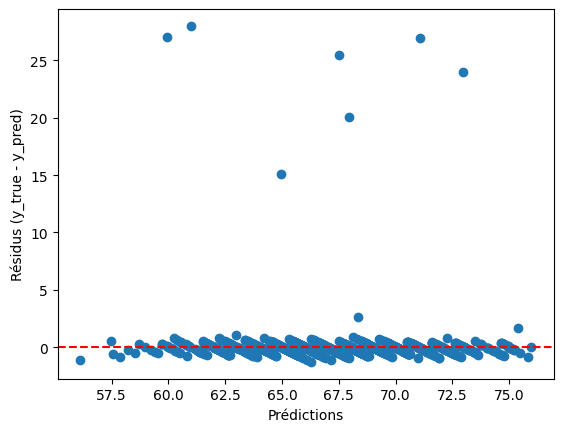

In [44]:
# Représentation des résidus
plt.scatter(y_pred_svr, y_test - y_pred_svr)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Prédictions")
plt.ylabel("Résidus (y_true - y_pred)")
plt.show()

Les résidus étant répartis autour de 0 indiquent qu'il ne semble pas y avoir de biais systématique; le modèle ne sous-estime ni ne surestime globalement les valeurs.
Cela valide également l'hypothèse d'homoscedasticité, montrant que l’erreur est indépendante de la valeur prédite.
Globalement, la relation linéaire capturée par le modèle SVR Linéaire paraît adaptée aux données.

## Interprétabilité et explicabilité
Pour un modèle linéaire, ALE ou ICE n’apportent rien de plus que les coefficients du modèle.

### PDP

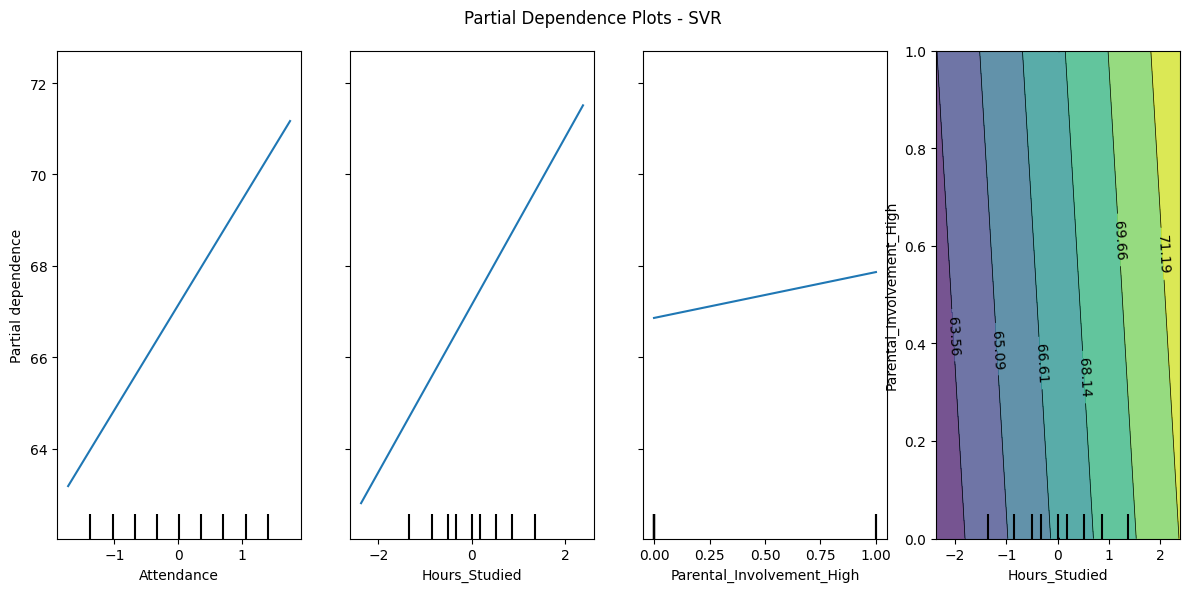

In [46]:
# PDP pour plusieurs caractéristiques 
# en prenant es 3 variables ayant le plus d'effet
features = ["Attendance","Hours_Studied","Parental_Involvement_High", ("Hours_Studied", "Parental_Involvement_High")]  
_, ax1 = plt.subplots(figsize = (12,6))
PartialDependenceDisplay.from_estimator(svr_final,  
                                         X_train_sc, 
                                         features,
                                         kind="average",
                                         ax = ax1,
                                         grid_resolution=50, 
                                         n_cols=4
                                         )
plt.suptitle("Partial Dependence Plots - SVR ")
plt.tight_layout()
plt.show()

### Permutation Feature Importance

In [47]:
result = permutation_importance(svr_final, X_train_sc, y_train,
                           n_repeats=15,
                           random_state=0,
                           scoring='neg_mean_squared_error'
                           )
pd.DataFrame(result.importances_mean, index=X_train_sc.columns, columns=['P-importance']).sort_values(by="P-importance", ascending=False)

,P-importance
Attendance,10.588042
Hours_Studied,6.359341
Previous_Scores,1.010611
Tutoring_Sessions,0.783434
Parental_Involvement_High,0.447924
Access_to_Resources_High,0.447245
Access_to_Resources_Low,0.336615
Parental_Involvement_Low,0.308066
Peer_Influence_Positive,0.134353
Family_Income_Low,0.123899


C:\Users\isali\AppData\Local\Temp\ipykernel_33488\2085684728.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(


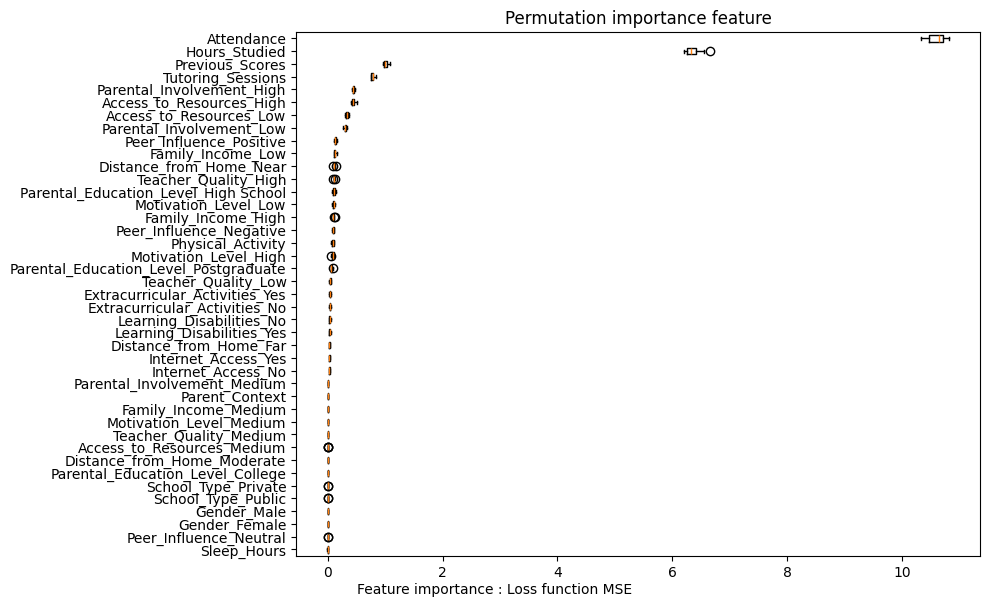

In [48]:
perm_sorted_idx = result.importances_mean.argsort()

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
ax1.boxplot(
    result.importances[perm_sorted_idx].T,
    vert=False,
    labels=X_train.columns[perm_sorted_idx]
)
plt.title('Permutation importance feature')
fig.text(.5, .001, "Feature importance : Loss function MSE", ha='center')

fig.tight_layout()
plt.show()

C:\Users\isali\AppData\Local\Temp\ipykernel_33488\2622731222.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


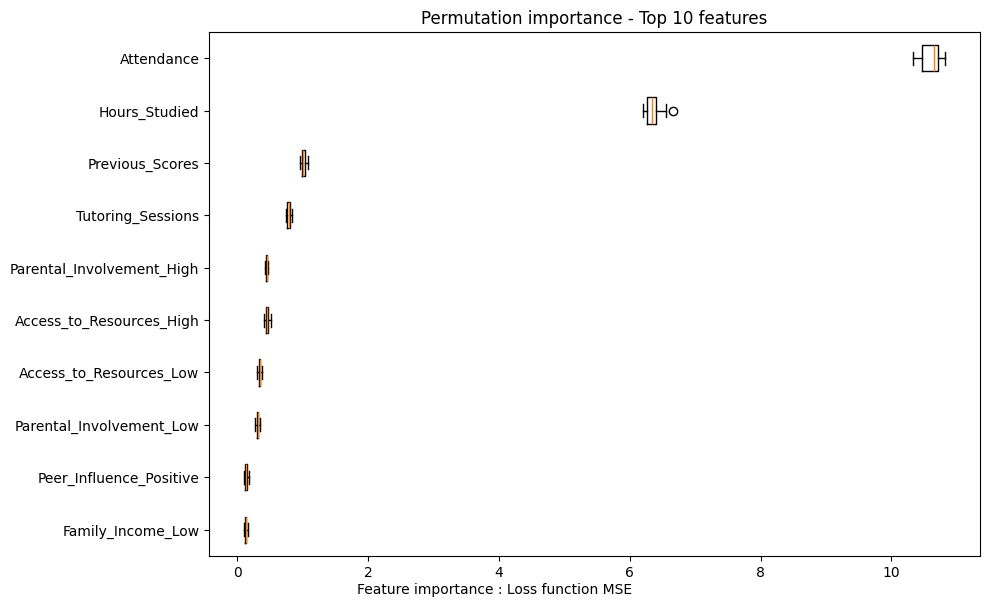

In [49]:
# Avec uniquement les 10 variables les plus importantes : 
# Tri des features par importance
perm_sorted_idx = result.importances_mean.argsort()

# Sélection des 10 features les plus importantes
top_n = 10
top_idx = perm_sorted_idx[-top_n:]

# Graphique
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.boxplot(
    result.importances[top_idx].T,  
    vert=False,
    labels=X_train.columns[top_idx]
)
plt.title(f'Permutation importance - Top {top_n} features')
fig.text(0.5, 0.001, "Feature importance : Loss function MSE", ha='center')

fig.tight_layout()
plt.show()

### LIME

In [50]:
from IPython.display import HTML

explainer = lime_tabular.LimeTabularExplainer(
    X_train_sc.to_numpy(),
    feature_names=X_train_sc.columns,
    verbose=True,
    mode='regression'
)

# Index de l'individu
i = 505

# Prédiction sur un array numpy
exp = explainer.explain_instance(X_train_sc.iloc[i].to_numpy(), svr_final.predict, num_features=5)

HTML(exp.as_html(show_table=True))

c:\Users\isali\Documents\cours\M2_ECAP\SVM_projet\projet_svm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


Intercept 66.84218997399228
Prediction_local [68.90088333]
Right: 69.30092519521466


LIME mesure l'effet local, pour un individu. Ainsi, les résultats peuvent ne pas suivre la tendance globale détectée par le modèle, comme c'est le cas ici. En effet, nous constatons que pour cet individu, le nombre d'heures étudiées et le nombre de sessions tutorées ont des effets négatifs sur sa note d'examen, tandis que c'est l'inverse dans la modèle globale.

### SHAP Values
#### Waterfall

100%|██████████| 99/99 [01:28<00:00,  1.12it/s]


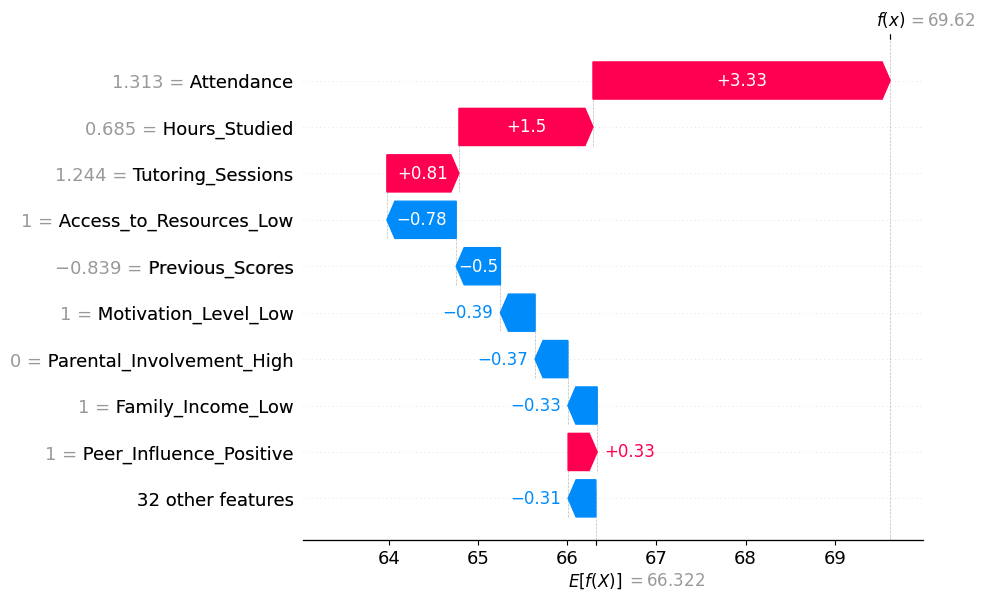

In [ ]:
# Initialisation de l'explainer, à partir de background_data 
# (pour calculer une valeur de base à partir de 50 lignes de X_train_sc)
background_data = shap.sample(X_train_sc, 50) 
explainer = shap.KernelExplainer(svr_final.predict, background_data)

# Calcul des valeurs SHAP sur un échantillon pour améliorer la vitesse de calcul
X_to_explain = X_train_sc.iloc[1:100]
shap_values = explainer(X_to_explain)

# Visualisation pour un individu spécifique (ici le 86ème de l'échantillon)
shap.initjs()
shap.plots.waterfall(shap_values[86])

#### Beeswarm

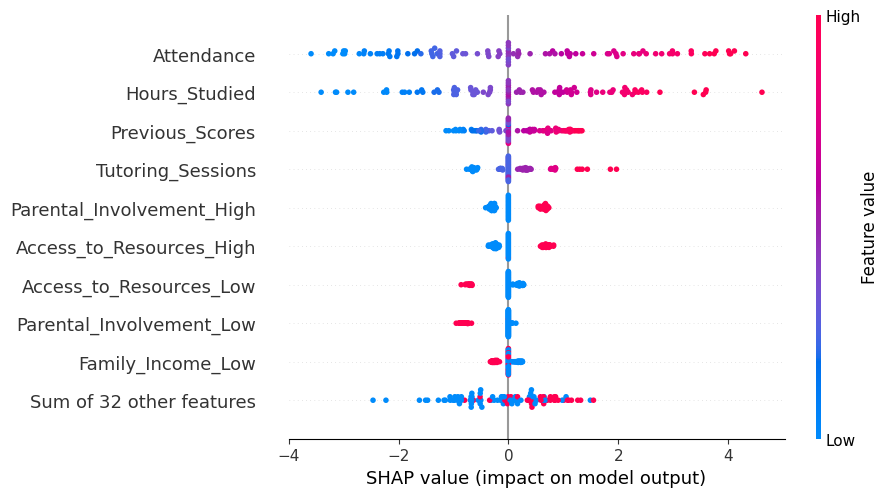

In [63]:
# Pour créer un objet Explanation compatible
shap_expl = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_train_sc.iloc[:100].to_numpy(),
    feature_names=X_train_sc.columns.tolist()
)

shap.plots.beeswarm(shap_expl)